In [14]:
import pickle
import torch
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression

# Load checkpoints and compute singular values by gate

In [1]:
def compose_weight_tensor(BASE_PATH, arg1, arg2, arg3 ):
    layers = [1,2]
    gates = ['forget', 'input', 'output', 'cell']
    weight_types = ['ih', 'hh']
    checkpoints = {}
    for layer in layers:
        for gate in gates:
            for weight_type in weight_types:
                check = []
                check.append(torch.load(f'{BASE_PATH}/layer{layer}_{gate}_gate_{weight_type}_{arg1}.pt'))
                check.append(torch.load(f'{BASE_PATH}/layer{layer}_{gate}_gate_{weight_type}_{arg2}.pt'))
                check.append(torch.load(f'{BASE_PATH}/layer{layer}_{gate}_gate_{weight_type}_{arg3}.pt'))
                check = torch.cat(check, dim=0)
                checkpoints[f'layer{layer}_{gate}_gate_{weight_type}'] = check
    return checkpoints
            

In [3]:
BASE_PATH = '/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam_full_check/weights'
checkpoints = compose_weight_tensor(
    BASE_PATH,
    'first100batches',
    'every100batches',
    'ep'
)

In [4]:
def get_sv_whole_layer(checkpoints, layer, num_checkpoints):

    layer_sv = []

    # For each checkpoint
    for i in range(num_checkpoints):
        # Stack all input-to-hidden weights
        ih_combined = torch.cat([
            checkpoints[f'layer{layer}_forget_gate_ih'][i],
            checkpoints[f'layer{layer}_input_gate_ih'][i],
            checkpoints[f'layer{layer}_cell_gate_ih'][i],
            checkpoints[f'layer{layer}_output_gate_ih'][i]
        ], dim=0)
        
        # Stack all hidden-to-hidden weights
        hh_combined = torch.cat([
            checkpoints[f'layer{layer}_forget_gate_hh'][i],
            checkpoints[f'layer{layer}_input_gate_hh'][i],
            checkpoints[f'layer{layer}_cell_gate_hh'][i],
            checkpoints[f'layer{layer}_output_gate_hh'][i]
        ], dim=0)
        
        # Combine all weights horizontally (concatenate along input dimension)
        #  ih is [hidden_size, input_size] and hh is [hidden_size, hidden_size] (https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
        all_weights = torch.cat([ih_combined, hh_combined], dim=1)
        
        # Compute singular values
        u, s, v = torch.svd(all_weights)
        
        # Store singular values for this checkpoint
        layer_sv.append(s)
        
    return layer_sv

In [5]:
sv_l1 = get_sv_whole_layer(checkpoints, 1, checkpoints['layer1_forget_gate_ih'].shape[0])

In [6]:
len(sv_l1)

232

In [12]:
sv_l1[0].shape

torch.Size([1300])

In [36]:
import pandas as pd
df = pd.read_csv('/scratch2/mrenaudin/colorlessgreenRNNs/evaluation_notebooks/results/lstm_adam_full_check')

In [37]:
df

,epoch,singular singular,singular plural,plural singular,plural plural
0,0,0.412,0.411,0.617,0.600
1,0,0.408,0.411,0.619,0.605
2,0,0.370,0.369,0.648,0.638
3,0,0.197,0.202,0.820,0.795
4,0,0.197,0.202,0.820,0.795
...,...,...,...,...,...
227,36,0.955,0.887,0.812,0.969
228,37,0.966,0.905,0.818,0.961
229,38,0.966,0.914,0.819,0.964
230,39,0.960,0.869,0.803,0.959


In [38]:
def add_checkpoint_index(df, batches_per_epoch=9269, first_epoch_batch_checkpoints=100, checkpoint_interval_after=100):
    df = df.copy()
    df['batch_within_epoch'] = df.groupby('epoch').cumcount()

    remaining_batches_epoch0 = batches_per_epoch - first_epoch_batch_checkpoints
    checkpoints_after_100 = remaining_batches_epoch0 // checkpoint_interval_after
    total_epoch0_checkpoints = first_epoch_batch_checkpoints + checkpoints_after_100

    def compute_checkpoint(row):
        epoch = row['epoch']
        batch = row['batch_within_epoch']

        if epoch == 0:
            if batch < first_epoch_batch_checkpoints:
                return batch
            else:
                offset = batch - first_epoch_batch_checkpoints
                if offset % checkpoint_interval_after == 0:
                    return first_epoch_batch_checkpoints + (offset // checkpoint_interval_after)
                else:
                    return None
        else:
            return total_epoch0_checkpoints + (epoch - 1)

    df['checkpoint'] = df.apply(compute_checkpoint, axis=1)

    # Keep only rows where checkpoint is not None
    df = df[df['checkpoint'].notnull()].reset_index(drop=True)
    df['checkpoint'] = df['checkpoint'].astype(int)  # make checkpoint int now that we dropped None

    return df


In [39]:
df = add_checkpoint_index(df)
print(df[['epoch', 'batch_within_epoch', 'checkpoint']])


     epoch  batch_within_epoch  checkpoint
0        0                   0           0
1        0                   1           1
2        0                   2           2
3        0                   3           3
4        0                   4           4
..     ...                 ...         ...
136     36                   0         226
137     37                   0         227
138     38                   0         228
139     39                   0         229
140     40                   0         230

[141 rows x 3 columns]


In [41]:
df

,epoch,singular singular,singular plural,plural singular,plural plural,batch_within_epoch,checkpoint
0,0,0.412,0.411,0.617,0.600,0,0
1,0,0.408,0.411,0.619,0.605,1,1
2,0,0.370,0.369,0.648,0.638,2,2
3,0,0.197,0.202,0.820,0.795,3,3
4,0,0.197,0.202,0.820,0.795,4,4
...,...,...,...,...,...,...,...
136,36,0.955,0.887,0.812,0.969,0,226
137,37,0.966,0.905,0.818,0.961,0,227
138,38,0.966,0.914,0.819,0.964,0,228
139,39,0.960,0.869,0.803,0.959,0,229


In [15]:


def compute_sliding_mi(sv_l1, sva_scores, window=10, top_k=1):
    """
    Compute mutual information between top-k singular values and SVA performance 
    using a sliding window approach.
    
    Parameters:
        sv_l1 (list of np.ndarray): List of shape [num_checkpoints], each [1300]
        sva_scores (np.ndarray): Array of SVA performance scores, shape [num_checkpoints]
        window (int): Size of the sliding window
        top_k (int): Number of top singular values to use as features
    
    Returns:
        pd.DataFrame: mutual information per sliding window
    """
    assert len(sv_l1) >= window and len(sva_scores) >= window, "Not enough data for given window size"
    
    # Preprocess: extract top-k singular values per checkpoint
    topk_svs = np.array([np.sort(s)[-top_k:][::-1] for s in sv_l1])  # shape [num_checkpoints, top_k]
    
    mi_vals = []
    window_indices = []

    for start in range(0, len(topk_svs) - window + 1):
        end = start + window
        X_win = topk_svs[start:end]            # shape (window, top_k)
        y_win = sva_scores[start:end]          # shape (window,)
        mi_components = mutual_info_regression(X_win, y_win, random_state=0)
        mi_total = mi_components.sum()         # sum MI across top_k components
        mi_vals.append(mi_total)
        window_indices.append((start, end - 1))

    mi_df = pd.DataFrame({
        'start_ckpt': [s for s, e in window_indices],
        'end_ckpt':   [e for s, e in window_indices],
        'mutual_info': mi_vals
    })

    return mi_df



In [17]:
from scipy.stats import entropy

def compute_entropy(y, bins='fd'):
    hist, _ = np.histogram(y, bins=bins)
    prob = hist / np.sum(hist)
    return entropy(prob + 1e-9)  # add small value to avoid log(0)

def compute_sliding_normalized_mi(sv_l1, sva_scores, window=10, top_k=1):
    topk_svs = np.array([np.sort(s)[-top_k:][::-1] for s in sv_l1])
    
    mi_vals = []
    nmi_vals = []
    window_indices = []

    for start in range(0, len(topk_svs) - window + 1):
        end = start + window
        X_win = topk_svs[start:end]
        y_win = sva_scores[start:end]

        mi = mutual_info_regression(X_win, y_win, random_state=0).sum()
        h_y = compute_entropy(y_win)
        nmi = mi / h_y if h_y > 0 else 0

        mi_vals.append(mi)
        nmi_vals.append(nmi)
        window_indices.append((start, end - 1))

    mi_df = pd.DataFrame({
        'start_ckpt': [s for s, e in window_indices],
        'end_ckpt':   [e for s, e in window_indices],
        'mutual_info': mi_vals,
        'normalized_mi': nmi_vals
    })

    return mi_df


In [46]:
from scipy.stats import entropy
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

def compute_entropy(y, bins='fd'):
    hist, _ = np.histogram(y, bins=bins)
    prob = hist / np.sum(hist)
    return entropy(prob + 1e-9)  # add small value to avoid log(0)

def compute_sliding_normalized_mi(sv_l1, sva_scores, window=10, top_k=1):
    topk_svs = np.array([np.sort(s)[-top_k:][::-1] for s in sv_l1])
    
    mi_vals = []
    nmi_vals = []
    window_indices = []
    for start in range(0, len(topk_svs) - window + 1):
        end = start + window
        X_win = topk_svs[start:end]
        print('X_win', X_win.shape)
        y_win = sva_scores[start:end]
        print('y_win', y_win.shape)
        
        # Calculate mutual information
        mi = mutual_info_regression(X_win.reshape(-1, 1), y_win, random_state=0)[0]
        print('mi', mi.shape)
        # Calculate entropy of both variables
        h_x = compute_entropy(X_win)
        print('h_x', h_x.shape)
        h_y = compute_entropy(y_win)
        print('h_y', h_y.shape)
        # Normalize using the minimum entropy (ensures value between 0 and 1)
        denominator = min(h_x, h_y)
        nmi = mi / denominator if denominator > 0 else 0
        
        # Ensure the value doesn't exceed 1 due to estimation errors
        nmi = min(nmi, 1.0)
        
        mi_vals.append(mi)
        nmi_vals.append(nmi)
        window_indices.append((start, end - 1))
    
    mi_df = pd.DataFrame({
        'start_ckpt': [s for s, e in window_indices],
        'end_ckpt':   [e for s, e in window_indices],
        'mutual_info': mi_vals,
        'normalized_mi': nmi_vals
    })
    return mi_df

In [47]:
# Example usage
# sv_l1_100: list of 100 np arrays of shape [1300]
# df['sva_perf']: performance values
conditions = ['singular singular', 'singular plural', 'plural plural','plural singular']
mi = {}
for condition in conditions:
    sv_l1_100 = sv_l1[:100]
    perf_100 = df[condition].values[:100]

    mi[condition] = compute_sliding_normalized_mi(sv_l1_100, perf_100, window=10, top_k=1)
    print(mi[condition])

print(mi)


X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_x ()
h_y ()
X_win (10, 1)
y_win (10,)
mi ()
h_

In [48]:
mi.keys()

dict_keys(['singular singular', 'singular plural', 'plural plural', 'plural singular'])

In [49]:
mi['singular plural']

,start_ckpt,end_ckpt,mutual_info,normalized_mi
0,0,9,0.286349,0.468761
1,1,10,0.192063,0.000000
2,2,11,0.066667,0.000000
3,3,12,0.000000,0.000000
4,4,13,0.033333,0.000000
...,...,...,...,...
86,86,95,0.179405,0.266570
87,87,96,0.253016,0.281772
88,88,97,0.529683,0.561492
89,89,98,0.549683,0.582693


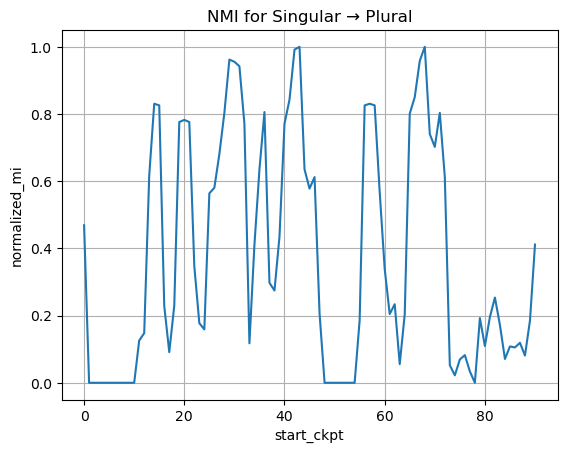

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=mi['singular singular'], 
             x='start_ckpt', y='normalized_mi')
plt.title('NMI for Singular → Plural')
plt.grid(True)
plt.show()

<Axes: xlabel='checkpoint', ylabel='singular plural'>

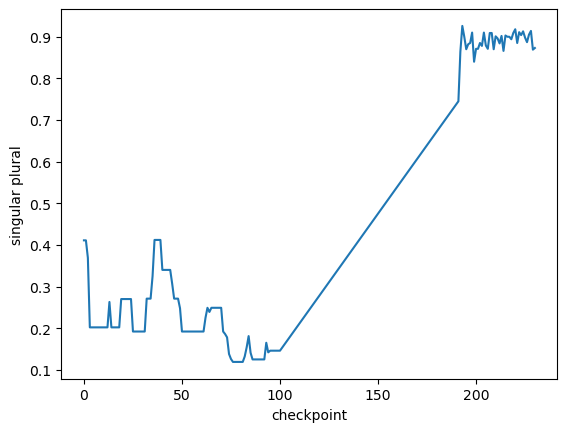

In [57]:
sns.lineplot(data=df, 
             x='checkpoint', y='singular plural')

In [55]:
df

,epoch,singular singular,singular plural,plural singular,plural plural,batch_within_epoch,checkpoint
0,0,0.412,0.411,0.617,0.600,0,0
1,0,0.408,0.411,0.619,0.605,1,1
2,0,0.370,0.369,0.648,0.638,2,2
3,0,0.197,0.202,0.820,0.795,3,3
4,0,0.197,0.202,0.820,0.795,4,4
...,...,...,...,...,...,...,...
136,36,0.955,0.887,0.812,0.969,0,226
137,37,0.966,0.905,0.818,0.961,0,227
138,38,0.966,0.914,0.819,0.964,0,228
139,39,0.960,0.869,0.803,0.959,0,229
